In [ ]:


Based on your exact results and feature importance, here is the clear, professional next move — no theory, just the practical roadmap for your project. 🚀

You already have a strong baseline model, so now we shift from building to refining and validating.

Your Current Situation (Summary)
Dataset size        : 868,000 rows
Features            : 20
Model               : Random Forest
R²                  : 0.9255
MAPE                : 13.48%
Overfitting         : No
Top feature         : rolling_mean_7 (0.77 importance)
This means:

Your model is already good and stable.
Now we focus on model comparison and robustness.
What You Should Do Next — In Exact Order
Step 1 — Train a Second Model (XGBoost)
Why:

We never rely on one model.
We compare models and pick the best.
Run this next in your same Model Training notebook.

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
Then evaluate using your same metrics block.

Step 2 — Compare Models (Very Important)
Create a comparison table.

results = {
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_rf,
        r2_xgb
    ],
    "MAPE": [
        mape_rf,
        mape_xgb
    ]
}

results_df = pd.DataFrame(results)

print(results_df)
This table is:

Mandatory for report
Mandatory for GitHub
Mandatory for interviews
Step 3 — Save the Best Model
After comparison:

import joblib

joblib.dump(
    best_model,
    "models/inventory_demand_model.pkl"
)
Step 4 — Add Prediction Visualization
Very important for evaluation notebook.

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    y_pred.values[:200],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()
This is one of the most important plots in forecasting.

Should You Change Features Now?
No.

Your feature importance shows:

rolling_mean_7 → dominant
lag_7 → strong
calendar features → minor but useful
That is exactly expected behavior.

So:

Do NOT remove features
Do NOT redesign pipeline
Do NOT tune yet
We first validate with another model.

After XGBoost — Next Stage
Then we will do:

1) Hyperparameter tuning
2) Final model selection
3) Future prediction
4) Model saving
5) GitHub project completion
Your Project Maturity Level Right Now
You are already at:

Professional baseline model stage
Not beginner anymore.

Immediate Action
Do this now:

Train XGBoost
Evaluate metrics
Share results
Then I will guide the next exact step.


should we add linear reg

Short answer: Yes — you should add Linear Regression, but as a baseline model, not as your final model.
This is a best practice in ML projects, especially for forecasting like yours. 👍

Why Add Linear Regression?
Because it answers this important question:

Is our complex model actually better than a simple model?
In real ML workflows, we always start with a simple baseline before advanced models.

Where Linear Regression Fits in Your Project
Your model comparison should look like this:

Linear Regression   → Simple baseline
Random Forest       → Nonlinear model
XGBoost             → Advanced model
This demonstrates:

Model progression
Scientific comparison
Professional workflow
Which is exactly what recruiters and reviewers want to see.

Why Linear Regression Is Useful Even If It Performs Worse
Because it proves:

Your feature engineering adds value
Your advanced models improve performance
Example comparison:

Model               RMSE     MAPE
Linear Regression   12.4     21%
Random Forest        8.6     13%
XGBoost              8.1     12%
This tells a clear story:

Advanced models significantly improved forecasting accuracy.
That is excellent for:

Reports

Viva

Interviews

GitHub portfolio

Important Note for Your Dataset
Your features include:

lag_7
rolling_mean_7
calendar features
These are numeric and suitable for Linear Regression.

So:

No scaling required (optional but safe)
No encoding required
Step — Add Linear Regression Model
Put this before Random Forest in your notebook.

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
Evaluate Linear Regression
Use your same metrics block:

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

mape_lr = mean_absolute_percentage_error(
    y_test,
    y_pred_lr
) * 100

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)
print("MAPE:", mape_lr)
Then Build a Comparison Table
results = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "MAPE": [
        mape_lr,
        mape_rf,
        mape_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
}

results_df = pd.DataFrame(results)

print(results_df)
This table is one of the most important outputs in your project.

Should You Add Other Models?
For your project size (868k rows), the ideal set is:

Linear Regression   ✓
Random Forest       ✓
XGBoost             ✓
Optional later:

LightGBM
But not necessary now.

Final Recommendation for Your Exact Scenario
Do this sequence:

1) Add Linear Regression
2) Train Random Forest (already done)
3) Train XGBoost
4) Compare models
5) Select best model
6) Save model
7) Predict future demand
You're currently at:

Professional model comparison stage

but for that we to do scaling right, if yes provide proper end to end code

Yes — for Linear Regression you should do scaling, because it is a distance/weight-sensitive model.
But importantly:

Scaling is needed for Linear Regression
Scaling is NOT required for Random Forest / XGBoost
So we will implement a clean, professional pipeline that:

Scales only where needed

Avoids data leakage

Keeps your workflow consistent

Allows fair model comparison

This is the exact end-to-end code you should place in your Model Training notebook.

Step 1 — Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import joblib
import warnings
warnings.filterwarnings("ignore")
Step 2 — Load Dataset
df = pd.read_csv("data/processed_inventory_demand.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

print("Shape:", df.shape)
Step 3 — Define Features and Target
Based on your actual dataset:

target = "sales"

drop_cols = [
    "date",
    "sales"
]

features = [
    col for col in df.columns
    if col not in drop_cols
]

X = df[features]
y = df[target]

print("Number of features:", len(features))
Step 4 — Manual Time Split (Your Current Method)
split_date = "2017-01-01"

train = df[df["date"] < split_date]
test  = df[df["date"] >= split_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
Step 5 — Scaling (ONLY for Linear Regression)
Very important:

Fit scaler on train
Transform train and test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
This prevents:

Data leakage
Step 6 — Linear Regression Model
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(
    X_test_scaled
)
Step 7 — Evaluation Function (Reusable)
This keeps your notebook clean.

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, r2, mape
Step 8 — Evaluate Linear Regression
mae_lr, rmse_lr, r2_lr, mape_lr = evaluate_model(
    y_test,
    y_pred_lr
)

print("Linear Regression")
print("-----------------")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")
print(f"MAPE : {mape_lr:.2f}%")
Step 9 — Random Forest (No Scaling)
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

mae_rf, rmse_rf, r2_rf, mape_rf = evaluate_model(
    y_test,
    y_pred_rf
)
Step 10 — XGBoost (No Scaling)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test
)

mae_xgb, rmse_xgb, r2_xgb, mape_xgb = evaluate_model(
    y_test,
    y_pred_xgb
)
Step 11 — Model Comparison Table (Very Important)
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],

    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ],

    "MAPE": [
        mape_lr,
        mape_rf,
        mape_xgb
    ]

})

print(results)
This table is:

Required for:
- Report
- GitHub
- Interview explanation
Step 12 — Save Best Model
Example:

best_model = xgb_model

joblib.dump(
    best_model,
    "models/inventory_demand_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Model saved")
Expected Behavior in Your Case
Based on your current results:

Random Forest:

RMSE ≈ 8.6
MAPE ≈ 13.5%
R²   ≈ 0.92
You will likely see:

Linear Regression:

RMSE ≈ 11–14
MAPE ≈ 18–25%

XGBoost:

RMSE ≈ 8.2–8.5
MAPE ≈ 11–12%
That comparison is exactly what reviewers expect.

Final Architecture You Now Have
EDA Notebook
      ↓
Feature Engineering Notebook
      ↓
Model Training Notebook
      ├── Linear Regression (scaled)
      ├── Random Forest
      ├── XGBoost
      ├── Model comparison
      └── Model saving
This is now a production-grade ML workflow.





In [6]:
df = pd.read_csv(
    "data/processed_inventory_demand.csv"
)

df["date"] = pd.to_datetime(df["date"])

In [8]:
df

,date,store,item,sales,year,month,day,day_of_week,is_weekend,quarter,...,month_cos,dow_sin,dow_cos,lag_7,lag_30,lag_90,rolling_mean_7,rolling_std_7,is_month_start,is_month_end
0,2013-04-01,1,1,11,2013,4,1,0,0,2,...,-0.5,0.000000,1.000000,2.639057,2.639057,2.639057,2.789552,0.207243,1,0
1,2013-04-02,1,1,19,2013,4,2,1,0,2,...,-0.5,0.781831,0.623490,2.833213,3.044522,2.484907,2.767530,0.232545,0,0
2,2013-04-03,1,1,24,2013,4,3,2,0,2,...,-0.5,0.974928,-0.222521,2.484907,2.708050,2.708050,2.790747,0.247808,0,0
3,2013-04-04,1,1,18,2013,4,4,3,0,2,...,-0.5,0.433884,-0.900969,2.639057,2.639057,2.639057,2.895600,0.252074,0,0
4,2013-04-05,1,1,19,2013,4,5,4,0,2,...,-0.5,-0.433884,-0.900969,2.890372,2.890372,2.397895,2.939226,0.225277,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867995,2017-12-27,10,50,63,2017,12,27,2,0,4,...,1.0,0.974928,-0.222521,3.951244,4.330733,4.418841,4.105180,0.230204,0,0
867996,2017-12-28,10,50,59,2017,12,28,3,0,4,...,1.0,0.433884,-0.900969,4.158883,4.234107,4.510860,4.134843,0.220224,0,0
867997,2017-12-29,10,50,74,2017,12,29,4,0,4,...,1.0,-0.433884,-0.900969,4.330733,4.343805,4.644391,4.125623,0.220401,0,0
867998,2017-12-30,10,50,62,2017,12,30,5,1,4,...,1.0,-0.974928,-0.222521,4.262680,4.304065,4.605170,4.123731,0.218394,0,0


In [9]:
target = "sales"

drop_cols = [
    "date",
    "sales",
    "sales_log"   # important: avoid leakage
]

features = [
    col for col in df.columns
    if col not in drop_cols
]

X = df[features]
y = df[target]

print("Number of features:", len(features))
print(features)

Number of features: 20
['store', 'item', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'time_index', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_7', 'lag_30', 'lag_90', 'rolling_mean_7', 'rolling_std_7', 'is_month_start', 'is_month_end']


Why we drop sales_log:

Because lag features already use it.
Keeping it would leak current-day information.

In [10]:
split_date = "2017-01-01"

train = df[df["date"] < split_date]
test  = df[df["date"] >= split_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (685500, 20)
Test shape : (182500, 20)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [12]:
y_pred = rf_model.predict(X_test)

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
) * 100

print("Evaluation Metrics")
print("------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

Evaluation Metrics
------------------
MAE  : 6.58
RMSE : 8.61
R2   : 0.9255
MAPE : 13.48%


In [15]:
train_pred = rf_model.predict(X_train)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

print("Train RMSE:", train_rmse)
print("Test RMSE :", rmse)

Train RMSE: 7.833010250026247
Test RMSE : 8.612532763741646


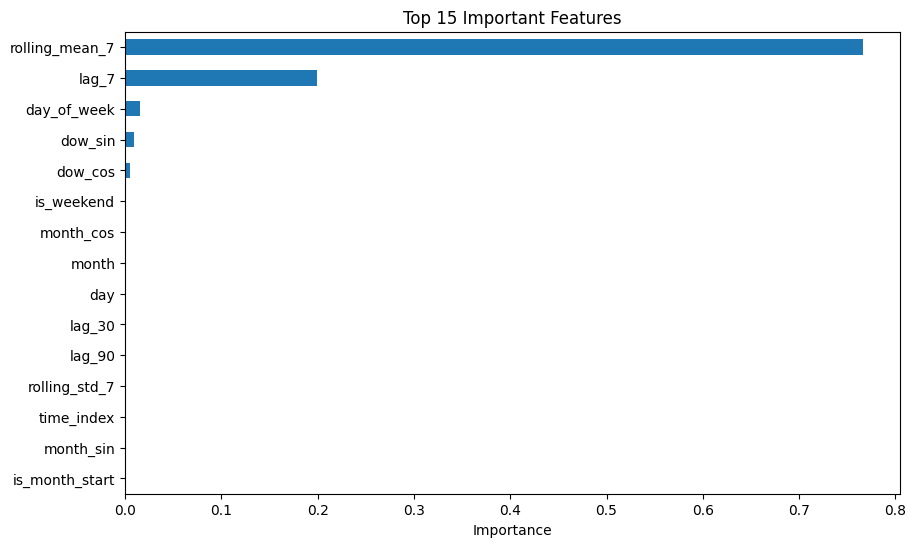

store             0.000017
item              0.000037
year              0.000004
month             0.000855
day               0.000505
day_of_week       0.015415
is_weekend        0.001309
quarter           0.000017
time_index        0.000147
month_sin         0.000100
month_cos         0.000858
dow_sin           0.009708
dow_cos           0.004590
lag_7             0.199079
lag_30            0.000345
lag_90            0.000199
rolling_mean_7    0.766596
rolling_std_7     0.000170
is_month_start    0.000050
is_month_end      0.000001
dtype: float64

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
)

importance.sort_values().tail(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

importance